In [1]:
import pathlib as pl

from argparse import ArgumentParser

import pandas as pd
import torch
import yaml

import airrtm.utils as au

from airrtm.cli.preprocess_sequences import METADATA_FILENAME
from airrtm.losses import CompositeLoss
from airrtm.models import model_factory
from airrtm.models.transformer_vae import SeqVAE
from airrtm.models.convolutional import ConvSeqVAE
from airrtm.training.train import train_model

import os

import pathlib as pl

import torch

from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

from airrtm.losses import CompositeLoss
from airrtm.models import AIRRTM_Model
from airrtm.types import AIRRTM_ModelOutput, AIRRTM_ModelTarget
from airrtm.utils import SequenceDataset

from settings import (
    PROJECT_DIR,
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    MAX_SEQUENCE_LENGTH,
    MIN_SEQUENCE_LENGTH,
    MIN_N_SEQUENCES,
    CONFIG_PATH,
    MODEL_DIR,
)

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

In [2]:
def _sample_other_repertoire_ids(
    repertoire_labels: torch.Tensor,
    n_sequences_per_batch: int,
) -> torch.Tensor:
    raise Exception("FIXME: use global list of rep ids to choose from")
    positive_repertoire_ids = torch.where(repertoire_labels == 1)[0]
    negative_repertoire_ids = torch.where(repertoire_labels == 0)[0]
    other_repertoire_ids = [
        negative_repertoire_ids if label == 1 else positive_repertoire_ids
        for label in repertoire_labels
    ]
    other_repertoire_ids = [
        repertoire_ids[
            torch.randint(
                low=0, high=repertoire_ids.shape[0], size=(n_sequences_per_batch,)
            )
        ]
        for repertoire_ids in other_repertoire_ids
    ]
    other_repertoire_ids = torch.concatenate(other_repertoire_ids)
    return other_repertoire_ids

In [3]:
MODEL_NAME = "per_rep_n_seq_1024_l1_0.0_z_mean_enc_16_16"
output_dir = MODEL_DIR / MODEL_NAME
input_dir = PROJECT_DIR / 'processed_data'
output_dir, input_dir





with open(CONFIG_PATH) as inp:
    config = yaml.safe_load(inp)
model_config = config["model_config"]
training_config = config["training_config"]

device = torch.device(training_config["device"])
seed = training_config["seed"]
torch.manual_seed(seed)

input_dir = pl.Path(input_dir)
metadata_df = pd.read_csv(input_dir / METADATA_FILENAME)
metadata_df = metadata_df.loc[metadata_df["split"] == "train"]

output_dir = pl.Path(output_dir)
output_dir.mkdir(exist_ok=True, parents=True)

log_dir = output_dir / training_config["log_dir_suffix"]
checkpoint_dir = output_dir / "checkpoints"

labels = torch.Tensor(metadata_df["label"].to_numpy()).to(torch.uint8)
sequences_datasets = [
    au.SequenceDataset.load(input_dir / f) for f in metadata_df["filename"]
    # au.SequenceDataset.load(input_dir / f)[torch.arange(5000)] for f in metadata_df["filename"]
]
shuffled_indices = [torch.randperm(d.size()) for d in sequences_datasets]
indices_train = [
    indices[int(indices.shape[0] * training_config["val_size"]) :]
    for indices in shuffled_indices
]
indices_val = [
    indices[: int(indices.shape[0] * training_config["val_size"])]
    for indices in shuffled_indices
]
sequences_datasets_train = [
    d[indices] for d, indices in zip(sequences_datasets, indices_train)
]
sequences_datasets_val = [
    d[indices] for d, indices in zip(sequences_datasets, indices_val)
]

# update config with the information from the training set
model_config["airrtm_params"]["n_repertoires"] = len(sequences_datasets)
max_sequence_length = sequences_datasets[0].max_length
alphabet_length = sequences_datasets[0].alphabet_length
model_config["encoder_params"]["max_sequence_length"] = max_sequence_length
model_config["encoder_params"]["alphabet_length"] = alphabet_length
model_config["decoder_params"]["max_sequence_length"] = max_sequence_length
model_config["decoder_params"]["alphabet_length"] = alphabet_length


# model = model_factory(**model_config)
model = torch.load(checkpoint_dir / f"checkpoint_epoch_{150}.py", weights_only=False).to(device)
# model = torch.load(
#     pl.Path("/Warehouse/Andrei/emerson/model/per_rep_n_seq_1024_l1_0.0_decreasing/checkpoints") / f"checkpoint_epoch_{47}.py",
#     weights_only=False,
# ).to(device)


n_sequences_per_repertoire_in_batch = training_config[
    "n_sequences_per_repertoire_in_batch"
]
n_repertoires_in_batch = training_config[
    "n_repertoires_in_batch"
]
total_batch_size = n_repertoires_in_batch * n_sequences_per_repertoire_in_batch
n_epochs = training_config["n_epochs"]
patience = training_config["patience"]


criterion = CompositeLoss(**training_config["loss_config"], n_sequences_per_repertoire=n_sequences_per_repertoire_in_batch)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=training_config["learning_rate"],
    weight_decay=training_config["weight_decay"],
)

sequence_datasets_train = sequences_datasets_train
sequence_datasets_val = sequences_datasets_val


repertoire_labels=labels

# keep_best_model = True
# checkpoint_dir.mkdir(parents=True, exist_ok=True)

In [10]:
import numpy as np
np.log(0.5)

np.float64(-0.6931471805599453)

In [4]:
writer = None

n_repertoires = len(sequence_datasets_train)
repertoire_sizes_train = [d.size() for d in sequence_datasets_train]
minimum_repertoire_size_train = min(repertoire_sizes_train)
repertoire_sizes_val = [d.size() for d in sequence_datasets_val]
minimum_repertoire_size_val = min(repertoire_sizes_val)

n_batches_per_repertoire_train = minimum_repertoire_size_train // n_sequences_per_repertoire_in_batch
max_topic_l1_coef = training_config["loss_config"]["topic_l1_coef"]
l1_coefs = np.linspace(0, max_topic_l1_coef, n_batches_per_repertoire_train)


n_batches_per_repertoire_val = minimum_repertoire_size_val // n_sequences_per_repertoire_in_batch

n_batches_train = n_batches_per_repertoire_train * (n_repertoires // n_repertoires_in_batch)
n_batches_val = n_batches_per_repertoire_val * (n_repertoires // n_repertoires_in_batch)

print(
    f"min rep size train: {minimum_repertoire_size_train}, min rep size val: {minimum_repertoire_size_val}"
)
print(
    f"max rep size train: {max(repertoire_sizes_train)}, max rep size val: {max(repertoire_sizes_val)}"
)
print(f"{n_batches_train=}, {n_batches_val=}")
print(f"{total_batch_size=}")
assert n_batches_train >= 1, n_batches_val >= 1

model = model.to(device)
early_stopping_counter = 0
best_val_loss = torch.inf
best_state_dict = model.state_dict().copy()
best_epoch = 0

loss_keys = ["total_loss"]
# if criterion.return_individual_compotents:
#     loss_keys.extend(
#         # ["recon_loss", "recon_acc", "kl_loss"]
#         ["recon_loss", "kl_loss"]
#     )
if criterion.return_individual_compotents:
    loss_keys.extend(
        ["reconstruction_accuracy", "kl_divergence", "tm_loss", "label_accuracy", "topic_l1_reg"]
    )

LOSS_KEY_TO_PRINT = {
    "total_loss": "total",
    "reconstruction_accuracy": "rec_acc",
    "kl_divergence": "kl_d",
    "tm_loss": "tm",
    "label_accuracy": "label_acc",
    "topic_l1_reg": "topic_l1",
}
train_loss_list = []
val_loss_list = []


min rep size train: 45302, min rep size val: 5033
max rep size train: 532565, max rep size val: 59173
n_batches_train=1628, n_batches_val=148
total_batch_size=16384


In [6]:
def _get_topic_strength(x_batch_SP, topic_id):
    return torch.nn.functional.sigmoid(
        model.latent_space_to_topic_proportions_layer(model.sequence_to_latent(x_batch_SP))
    )[:, topic_id].detach().to("cpu")
def predict_signal_intensity_2(x_batch_SP):
    return torch.nn.functional.sigmoid(model.repertoire_label_prediction_layer(
        torch.nn.functional.sigmoid(model.latent_space_to_topic_proportions_layer(
            model.sequence_to_latent(x_batch_SP)
        ))[:, :model.n_topics_signal]  
    )).detach().to("cpu")
# with torch.no_grad():
#     print(predict_signal_intensity_2(x_batch_SP))
# with torch.no_grad():
#     print(torch.nn.functional.sigmoid(model.repertoire_label_prediction_layer(
#         torch.nn.functional.sigmoid(model.latent_space_to_topic_proportions_layer(
#             model.sequence_to_latent(x_batch_SP)
#         ))[:, :model.n_topics_signal]  
#     )))
    # print(
    #     torch.nn.functional.sigmoid(model.latent_space_to_topic_proportions_layer(
    #         model.sequence_to_latent(x_batch_SP)
    #     ))[:, :model.n_topics_signal]  
    # )

In [7]:
# # q_l1 = (predict_signal_intensity_2(x_batch_SP) > 0.5).float().mean().item()
# q_l1 = val_loss_list[1]["topic_l1_reg"]
# # q_l1 = 0.27909876552930984
# q_l1

<Axes: ylabel='Percent'>

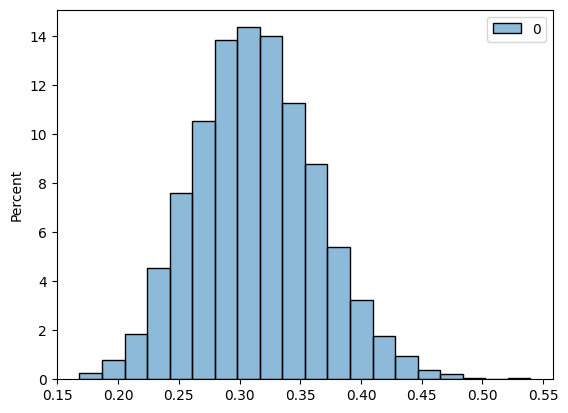

In [16]:
# sns.histplot(predict_signal_intensity_2(x_batch_SP), bins=np.linspace(0, 1, 101), stat="percent")
sns.histplot(predict_signal_intensity_2(x_batch_SP), bins=20, stat="percent")

In [8]:
model.repertoire_label_prediction_layer.weight

Parameter containing:
tensor([[ 0.2822,  0.2262,  0.4391, -0.5645, -0.3611,  0.4334,  0.4224, -0.2875,
         -0.2597, -0.4967,  0.4074,  0.3070,  0.2829, -0.4580,  0.2873,  0.3467,
         -0.2491, -0.4000,  0.2487, -0.5448]], device='cuda:0',
       requires_grad=True)

In [9]:
model._compute_signal_topic_weights(repertoire_labels_R=repertoire_labels, label_of_interest=1)

tensor([-0.0412, -0.0632, -0.0270, -0.0473,  0.0254,  0.0683,  0.0612,  0.0442,
        -0.0258,  0.0849, -0.0002, -0.0957,  0.0739,  0.0432,  0.0361, -0.0424,
        -0.0643, -0.0142,  0.0511,  0.0901], device='cuda:0',
       grad_fn=<MulBackward0>)

In [10]:
# qs = [1 - x for x in (0, 5e-5, 1e-4, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3, 1e-2, 2e-2, 5e-2, 1e-1, 2e-1, 3e-1, q_l1, 4e-1)]
# qs = [1 - q_l1 + x.item() for x in np.linspace(-0.04, 0.04, 41)]
# qs = [1 - q_l1 + x.item() for x in np.linspace(-0.25, 0.25, 41)]
signal_intensities_by_repertoire_train = []
for sd in tqdm(sequences_datasets_train):
    batch_size = 4096
    signal_intensities = []
    for batch_start in range(0, sd.size(), batch_size):
        signal_intensities_batch = predict_signal_intensity_2(
            sd.data[batch_start:batch_start+batch_size].to(device)
        ).to("cpu").detach()
        # signal_intensities_batch = model.predict_signal_intensity(
        #     sd.data[batch_start:batch_start+batch_size].to(device), repertoire_labels_R=repertoire_labels
        # ).to("cpu").detach()
        # signal_intensities_batch = _get_topic_strength(
        #     sd.data[batch_start:batch_start+batch_size].to(device), topic_id=1
        # )
        signal_intensities.append(signal_intensities_batch)
    signal_intensities = torch.concatenate(signal_intensities)
    signal_intensities_by_repertoire_train.append(signal_intensities)
# quantiles = [torch.quantile(signal_intensities, q=q).item() for q in qs] + [signal_intensities.mean().item()]
# quantiles_train.append(quantiles)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 597/597 [14:58<00:00,  1.50s/it]


In [11]:
signal_intensities_by_repertoire_val = []
for sd in tqdm(sequences_datasets_val):
    batch_size = 4096 * 4
    signal_intensities = []
    for batch_start in range(0, sd.size(), batch_size):
        signal_intensities_batch = predict_signal_intensity_2(
            sd.data[batch_start:batch_start+batch_size].to(device)
        ).to("cpu").detach()
        # signal_intensities_batch = model.predict_signal_intensity(
        #     sd.data[batch_start:batch_start+batch_size].to(device), repertoire_labels_R=repertoire_labels
        # ).to("cpu").detach()
        # signal_intensities_batch = _get_topic_strength(
        #     sd.data[batch_start:batch_start+batch_size].to(device), topic_id=1
        # )
        signal_intensities.append(signal_intensities_batch)
    signal_intensities = torch.concatenate(signal_intensities)
    signal_intensities_by_repertoire_val.append(signal_intensities)
# quantiles = [torch.quantile(signal_intensities, q=q).item() for q in qs] + [signal_intensities.mean().item()]
# quantiles_val.append(quantiles)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 597/597 [01:39<00:00,  6.01it/s]


In [12]:
qs = [1 - x for x in (0, 5e-5, 1e-4, 1 / n_sequences_per_repertoire_in_batch, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3, 1e-2, 2e-2, 5e-2, 1e-1, 2e-1, 3e-1, 4e-1)]
# qs = [1 - q_l1 + x.item() for x in np.linspace(-0.04, 0.04, 41)]
# qs = [1 - q_l1 + x.item() for x in np.linspace(-0.25, 0.25, 41)]
quantiles_train = [
    torch.quantile(signal_intensities, q=torch.tensor(qs)).detach().numpy().tolist() + [signal_intensities.mean().item()]
    for signal_intensities in signal_intensities_by_repertoire_train
]
# quantiles_train.append(quantiles)


In [13]:
quantiles_val = [
    torch.quantile(signal_intensities, q=torch.tensor(qs)).detach().numpy().tolist() + [signal_intensities.mean().item()]
    for signal_intensities in signal_intensities_by_repertoire_val
]

In [14]:
df = pd.DataFrame()
for i, q in enumerate(qs):
    df[str(q)] = [t[i] for t in quantiles_train]
df["mean"] = [t[-1] for t in quantiles_train]
df["label"] = repertoire_labels
df_long = pd.melt(df, id_vars=["label"], value_vars=[str(q) for q in qs] + ["mean"], var_name="q", value_name="signal_intensity")

In [15]:
df_val = pd.DataFrame()
for i, q in enumerate(qs):
    df_val[str(q)] = [t[i] for t in quantiles_val]
df_val["mean"] = [t[-1] for t in quantiles_val]
df_val["label"] = repertoire_labels
df_val_long = pd.melt(df_val, id_vars=["label"], value_vars=[str(q) for q in qs] + ["mean"], var_name="q", value_name="signal_intensity")

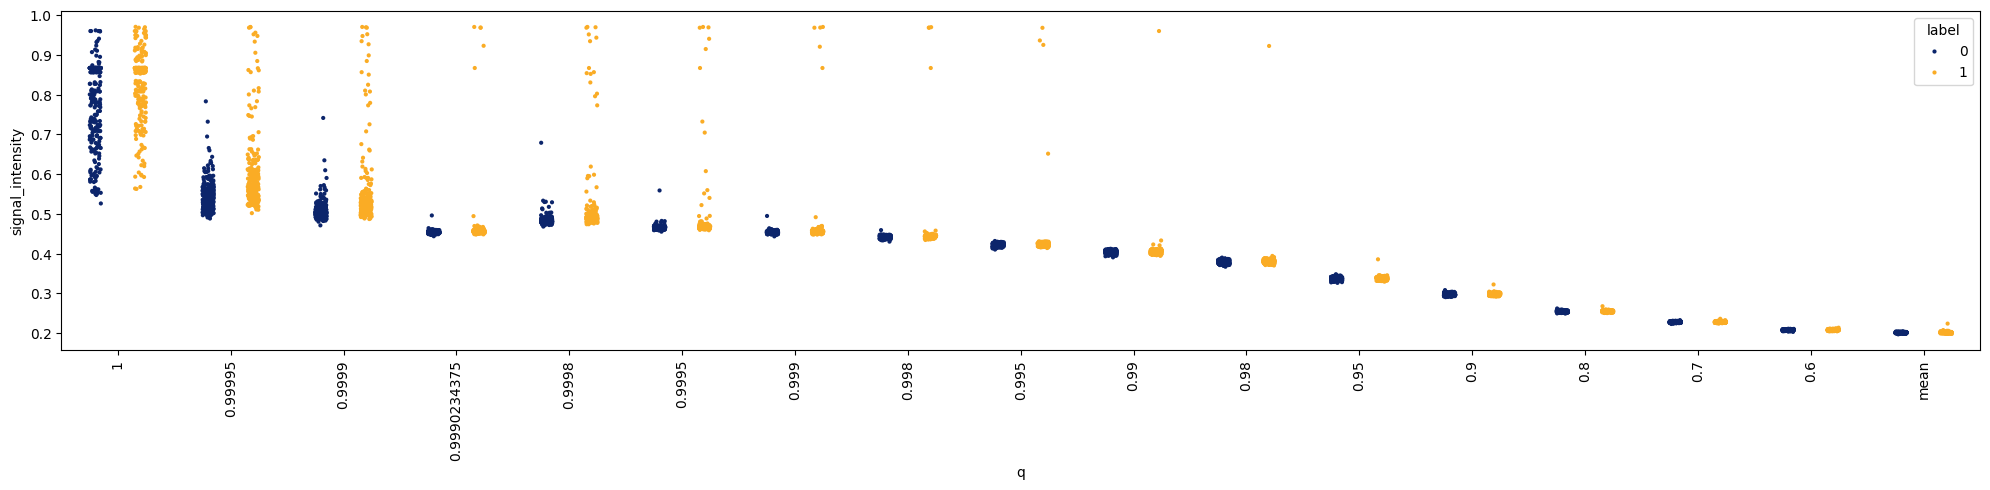

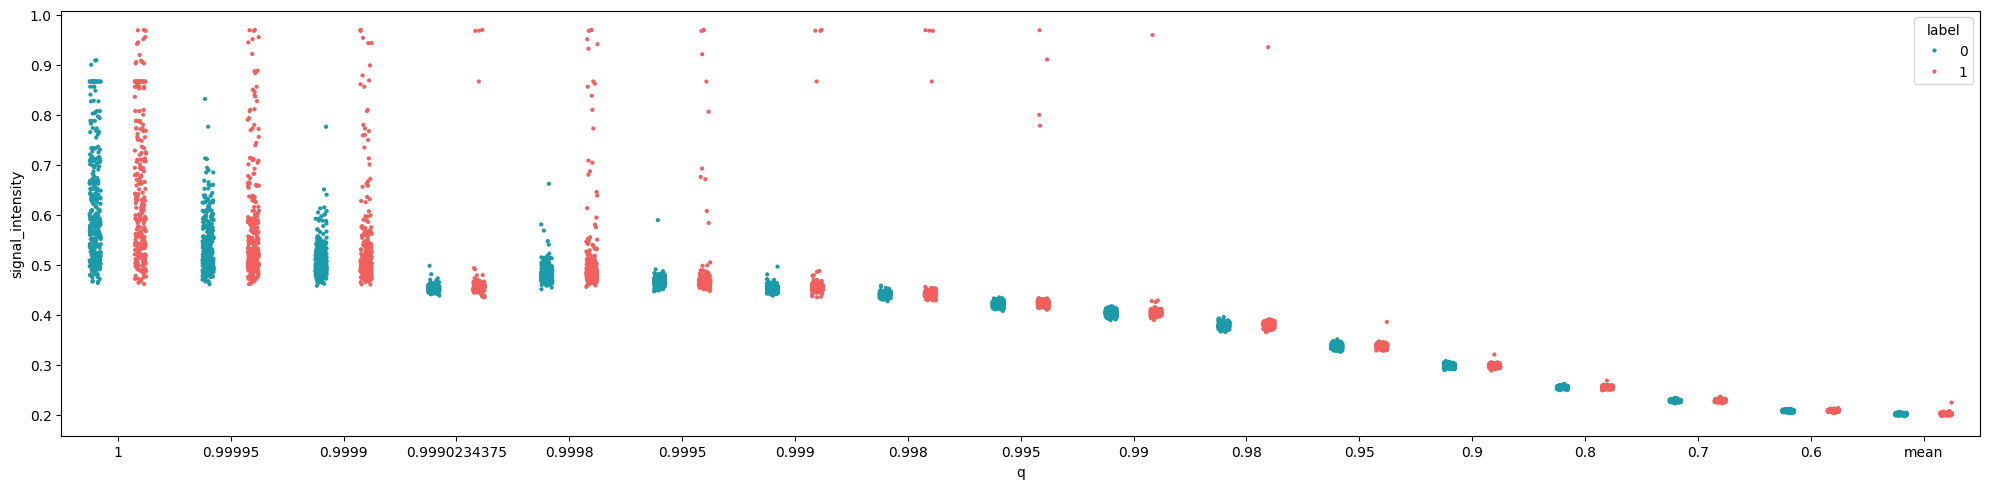

In [16]:
color_1 = "#0C256B"
color_2 = "#FAAC25"
color_3 = "#1B9AAA"
color_4 = "#F25F5C"

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 5))

sns.stripplot(
    data=df_long,
    # data=df_long.loc[df_long["q"] == "mean"],
    x="q",
    y="signal_intensity",
    hue="label",
    palette=[color_1, color_2],
    dodge=True,
    s=3,
    ax=ax,
)
# ax.set_yscale("log")
ax.tick_params(axis="x", rotation=90)
fig.tight_layout()
fig.show()


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 5))

sns.stripplot(
    data=df_val_long,
    # data=df_val_long.loc[df_val_long["q"] == "mean"],
    x="q",
    y="signal_intensity",
    hue="label",
    palette=[color_3, color_4],
    dodge=True,
    s=3,
    ax=ax,
)
# ax.set_yscale("log")


fig.tight_layout()
fig.show()

In [8]:
(0.6738 - 0.6931) * 100

-1.9300000000000095

In [48]:
"acatctgaggactctgcggtctattactgt".upper()

'ACATCTGAGGACTCTGCGGTCTATTACTGT'

In [2]:
import torch

In [6]:
-torch.log(torch.tensor([0.5]))

tensor([0.6931])

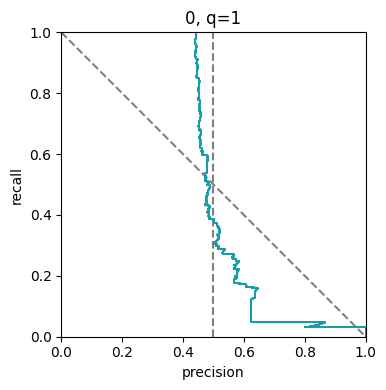

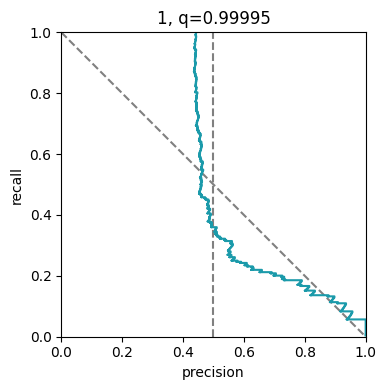

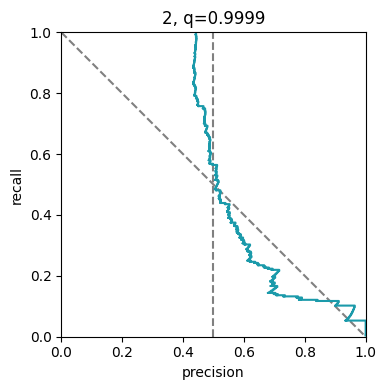

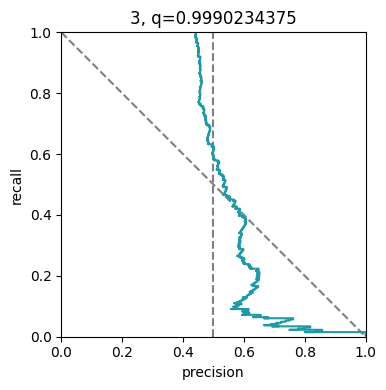

In [46]:
eps = 1e-12

for k in range(4):
    y_pred = np.array(quantiles_val)[:, k]
    precisions = []
    recalls = []
    
    for t in sorted(set(y_pred)):
    
        y_pred_binary = y_pred >= t
        TP = ((y_pred_binary == 1) & (repertoire_labels.numpy() == 1)).sum()
        P = (repertoire_labels.numpy() == 1).sum()
        PP = (y_pred_binary == 1).sum()
        precision = TP / (PP + eps)
        recall = TP / (P + eps)
        precisions.append(precision.item())
        recalls.append(recall.item())
    

    # pr_pairs = sorted(zip(precisions, recalls))
    # precisions = [p for p, r in pr_pairs]
    # recalls = [r for p, r in pr_pairs]
    
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
    
    
    
    ax.axvline(0.5, color="grey", linestyle="--")
    ax.plot([0, 1], [1, 0], color="grey", linestyle="--")
    
    ax.plot(np.repeat(precisions, 2)[:-1], np.repeat(recalls, 2)[1:], color=color_3)
    # ax.set_yscale("log")
    
    ax.set_xlim((0, 1))
    ax.set_ylim((0, 1))
    
    ax.set_xlabel("precision")
    ax.set_ylabel("recall")

    
    ax.set_title(f"{k}, q={qs[k]}")
    
    ax.set_aspect("equal")
    fig.tight_layout()
    fig.show()



# precision, recall, 2 * precision * recall / (precision + recall)



# xx_pos = np.array(quantiles_val)[:, k][repertoire_labels == 1]
# xx_neg = np.array(quantiles_val)[:, k][repertoire_labels == 0]
# repertoire_labels[xx < t].float().mean()# == repertoire_labels

 25%|█████████████████████████████████▊                                                                                                   | 152/597 [20:21<59:35,  8.04s/it]


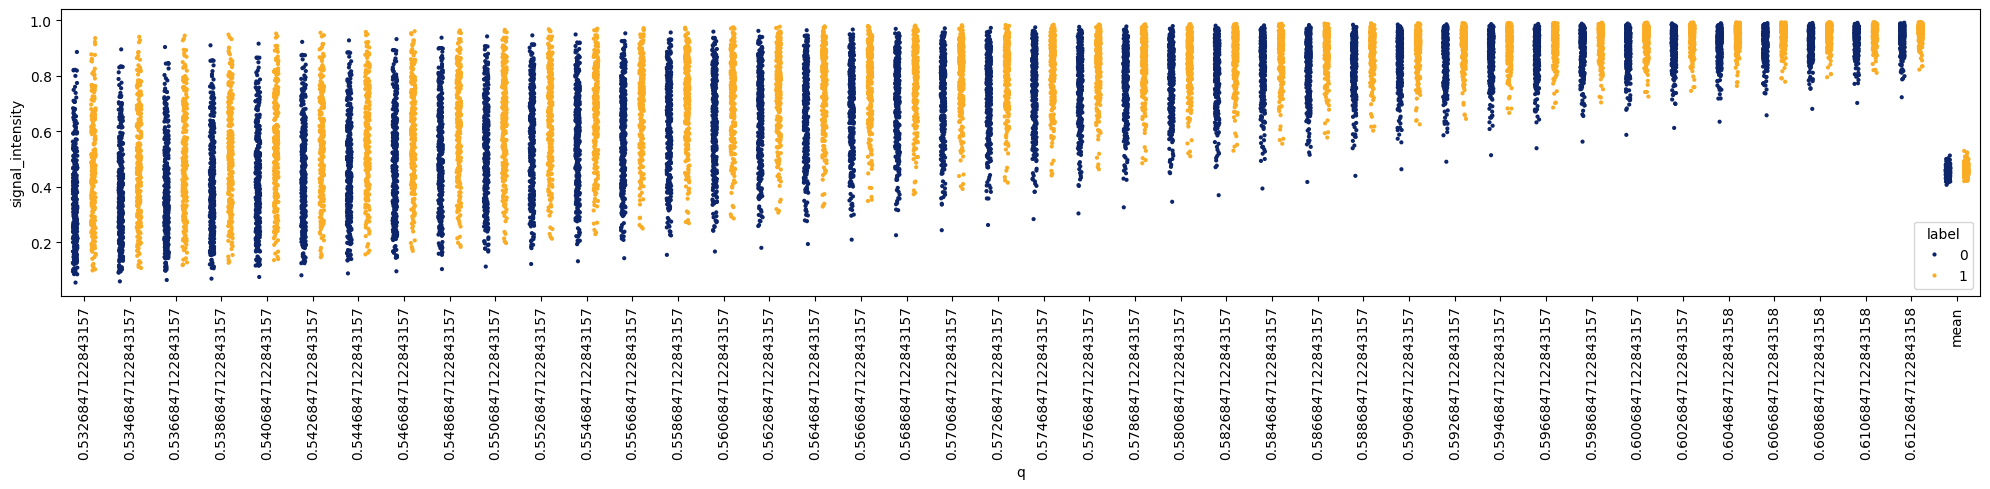

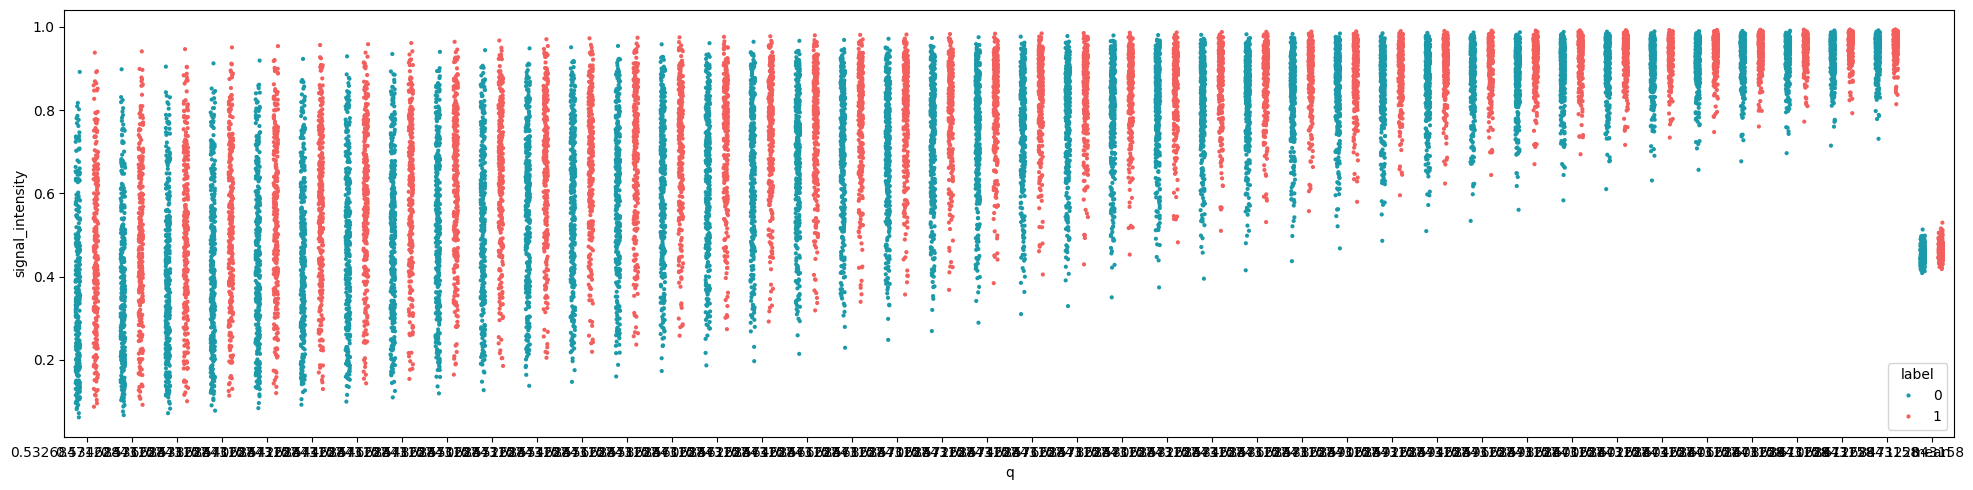

/tmp/ipykernel_3590041/2795341589.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(len(qs) + 1))
/tmp/ipykernel_3590041/2795341589.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(len(qs) + 1))


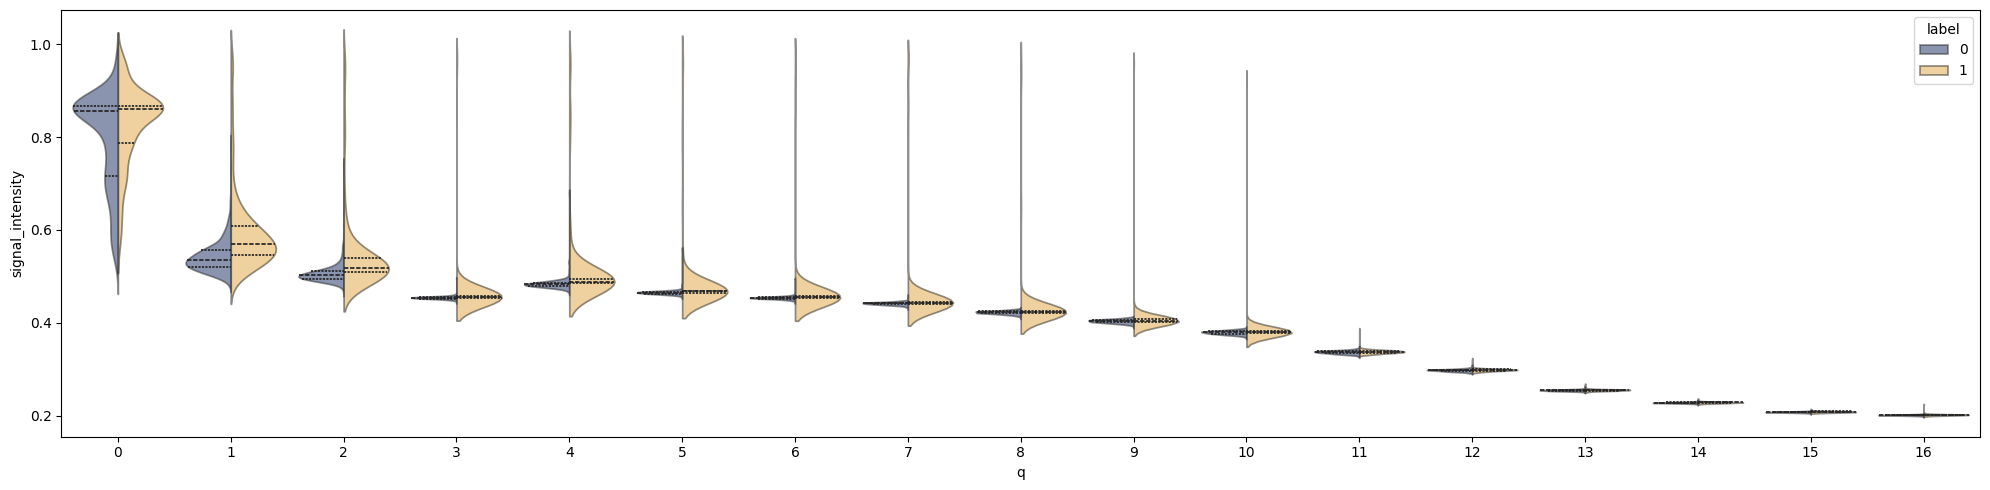

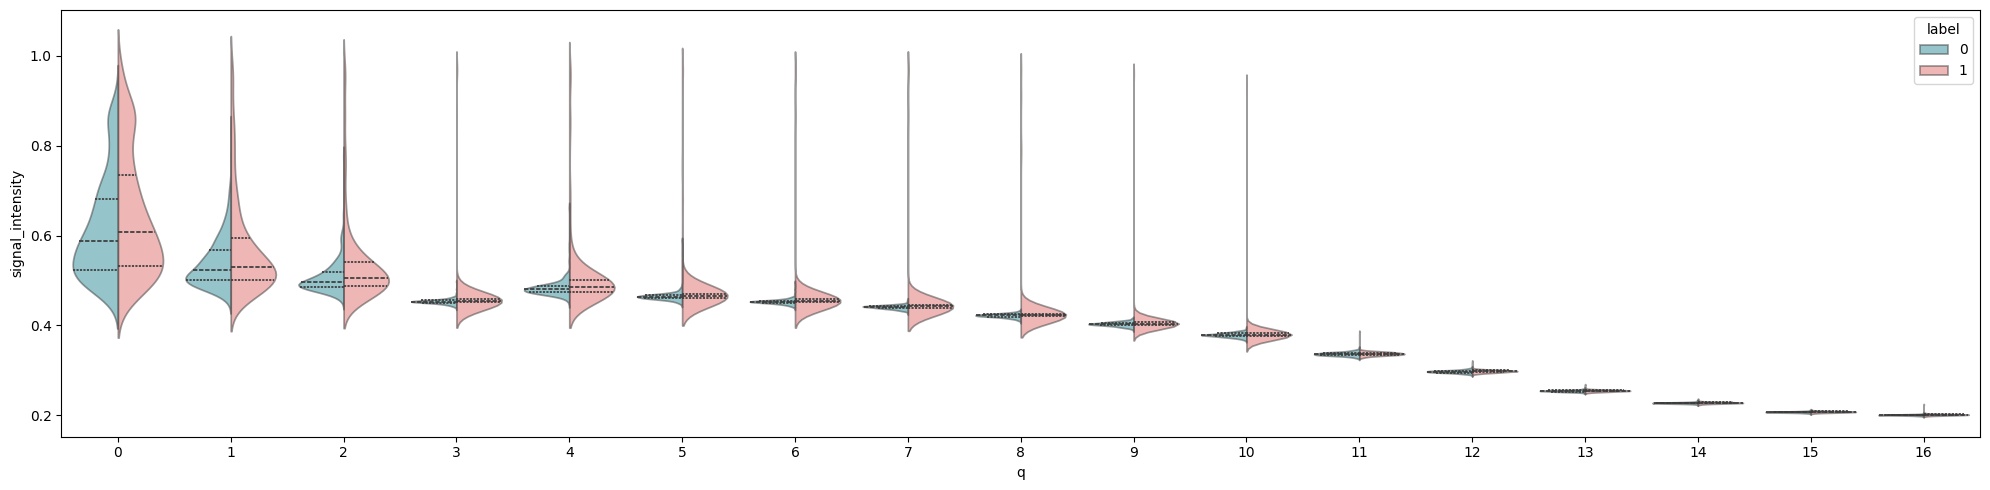

In [17]:
color_1 = "#0C256B"
color_2 = "#FAAC25"
color_3 = "#1B9AAA"
color_4 = "#F25F5C"

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 5))

sns.violinplot(
    data=df_long,
    # data=df_long.loc[df_long["q"].isin([str(q) for q in qs[16:26]])],
    x="q",
    y="signal_intensity",
    hue="label",
    palette=[color_1, color_2],
    dodge=True,
    # s=3,
    ax=ax,
    density_norm="count",
    split=True,
    inner="quart",
    alpha=0.5,
)
# ax.set_xticks([])
ax.set_xticklabels(np.arange(len(qs) + 1))
# ax.set_yscale("log")

fig.tight_layout()
fig.show()


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 5))

sns.violinplot(
    data=df_val_long,
    # data=df_long.loc[df_long["q"].isin([str(q) for q in qs[16:26]])],
    x="q",
    y="signal_intensity",
    hue="label",
    palette=[color_3, color_4],
    dodge=True,
    # s=3,
    ax=ax,
    density_norm="count",
    split=True,
    inner="quart",
    alpha=0.5,
)
ax.set_xticklabels(np.arange(len(qs) + 1))
# ax.set_yscale("log")


fig.tight_layout()
fig.show()

/tmp/ipykernel_2996906/2795341589.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(len(qs) + 1))
/tmp/ipykernel_2996906/2795341589.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(len(qs) + 1))


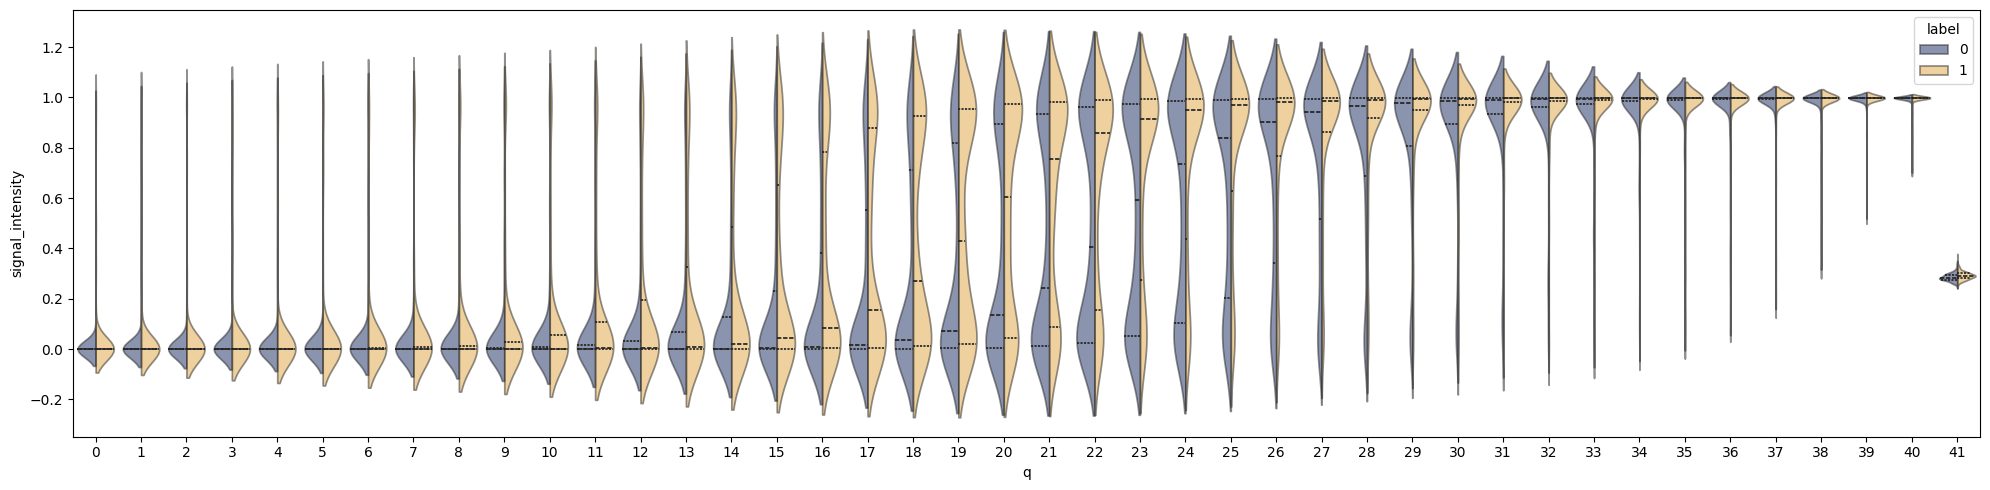

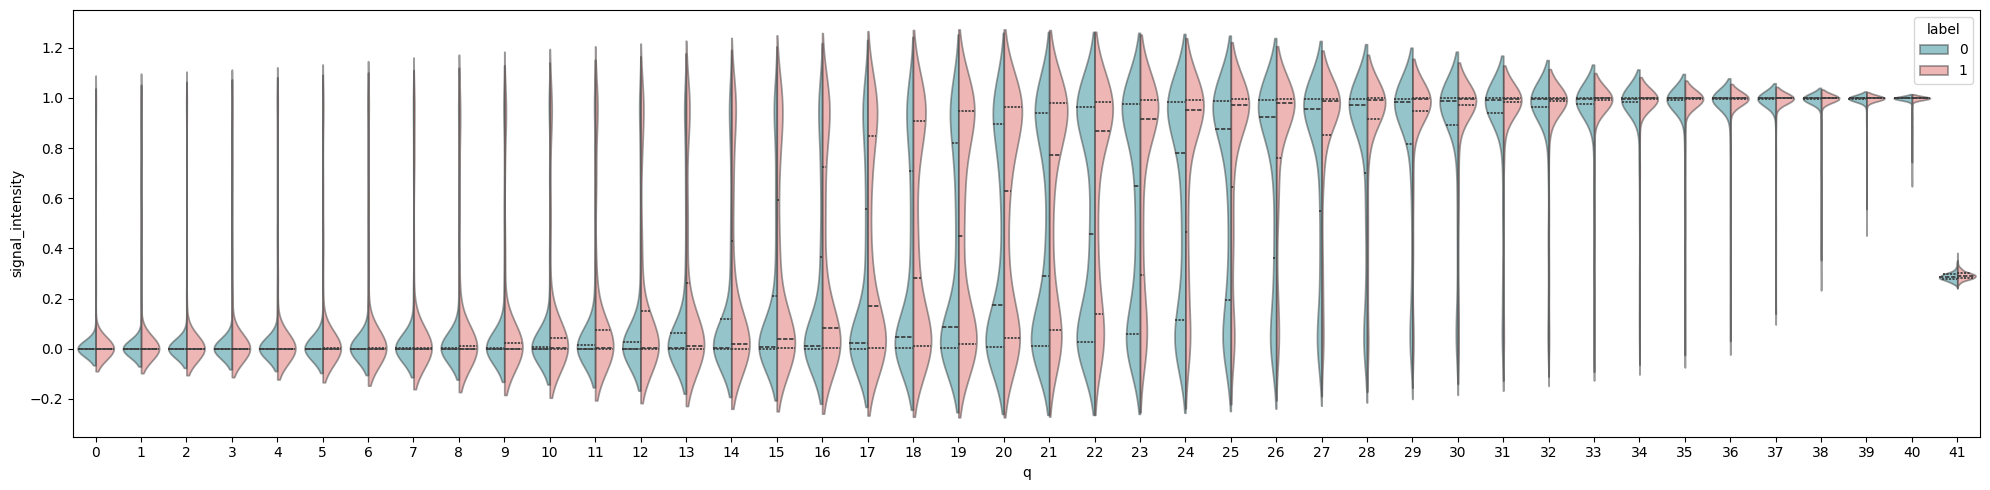

/tmp/ipykernel_3590041/3718588339.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(len(qs) + 1))
/tmp/ipykernel_3590041/3718588339.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(len(qs) + 1))


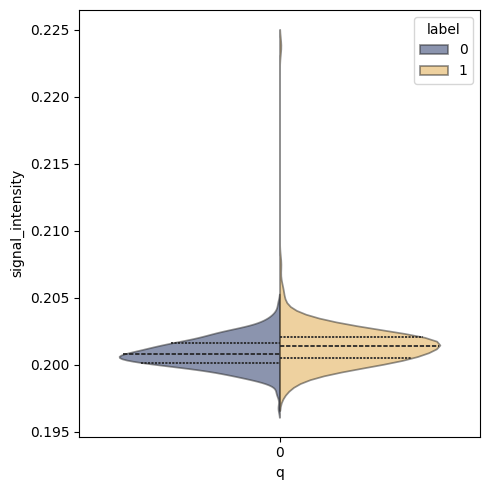

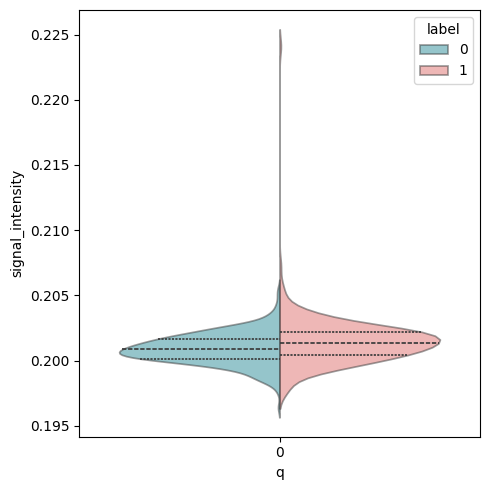

In [18]:
color_1 = "#0C256B"
color_2 = "#FAAC25"
color_3 = "#1B9AAA"
color_4 = "#F25F5C"

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

sns.violinplot(
    # data=df_long,
    data=df_long.loc[df_long["q"] == "mean"],
    x="q",
    y="signal_intensity",
    hue="label",
    palette=[color_1, color_2],
    dodge=True,
    # s=3,
    ax=ax,
    density_norm="width",
    split=True,
    inner="quart",
    alpha=0.5,
)
# ax.set_xticks([])
ax.set_xticklabels(np.arange(len(qs) + 1))
# ax.set_yscale("log")

fig.tight_layout()
fig.show()


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

sns.violinplot(
    # data=df_val_long,
    data=df_val_long.loc[df_val_long["q"] == "mean"],
    x="q",
    y="signal_intensity",
    hue="label",
    palette=[color_3, color_4],
    dodge=True,
    # s=3,
    ax=ax,
    density_norm="width",
    split=True,
    inner="quart",
    alpha=0.5,
)
ax.set_xticklabels(np.arange(len(qs) + 1))
# ax.set_yscale("log")


fig.tight_layout()
fig.show()

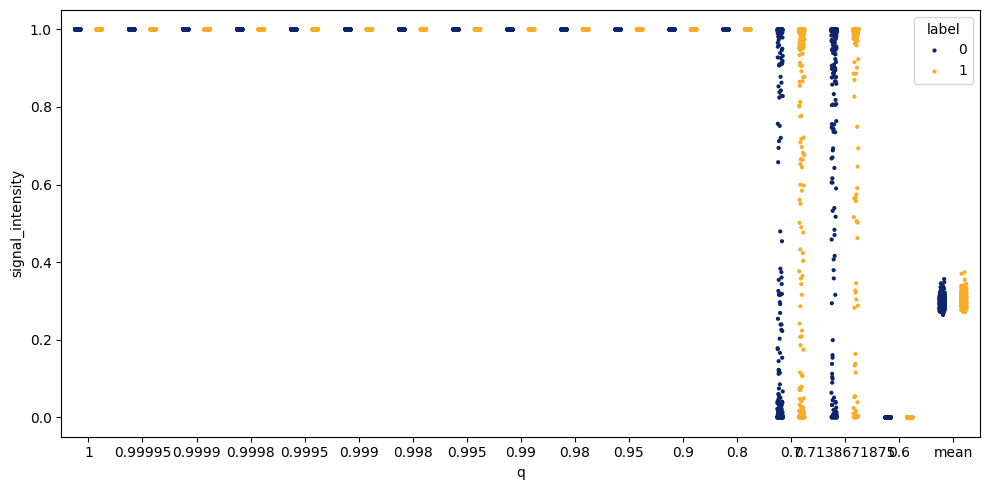

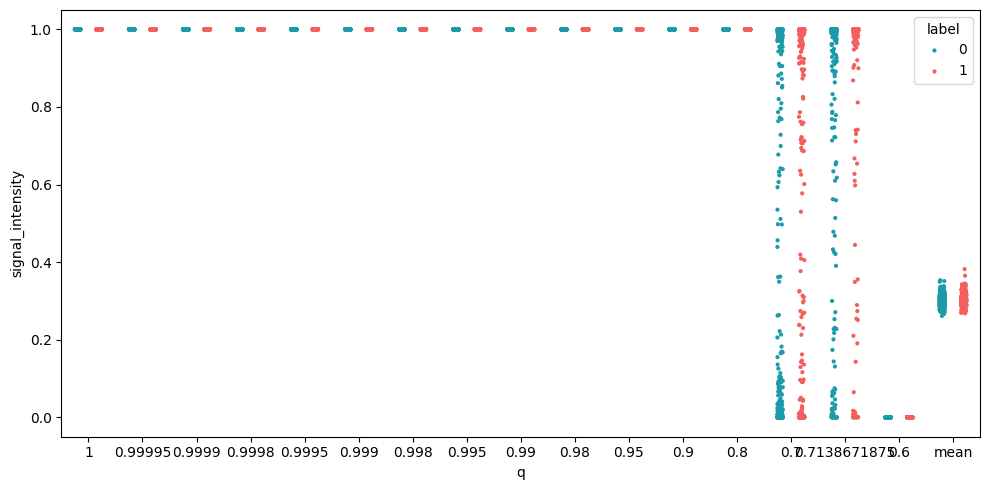

In [ ]:
np.array(quantiles_val[])

In [19]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

In [38]:
clf = RandomForestClassifier(max_depth=1, n_estimators=100)#, max_features=None)
# clf.fit(np.array(quantiles_train)[:, 8:21], repertoire_labels)
clf.fit(np.array(quantiles_train), repertoire_labels)

,n_estimators,100
,criterion,'gini'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
# (clf.predict(np.array(quantiles_train)[:, 8:21]) == repertoire_labels).float().mean()
(clf.predict(np.array(quantiles_train)) == repertoire_labels).float().mean()

tensor(0.7286)

In [40]:
# (clf.predict(np.array(quantiles_val)[:, 8:21) == repertoire_labels).float().mean()
(clf.predict(np.array(quantiles_val)) == repertoire_labels).float().mean()

tensor(0.6147)

In [44]:
t = 0.6
k = 1
((np.array(quantiles_train)[:, k] > t) == repertoire_labels).float().mean(), ((np.array(quantiles_val)[:, k] > t) == repertoire_labels).float().mean()

(tensor(0.6533), tensor(0.5946))

In [287]:
repertoire_labels.float().mean()

tensor(0.4422)

In [293]:
sorted(set(y_pred))[140] 

np.float64(0.5129997730255127)

In [294]:
precisions[140]

0.48796498905907987

In [295]:
recalls[140]

0.8446969696969664

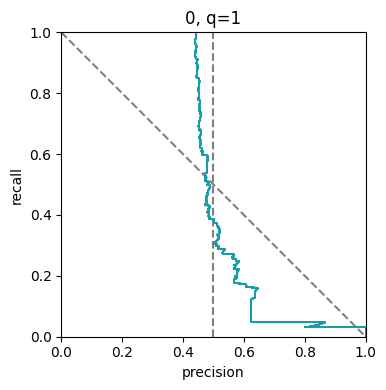

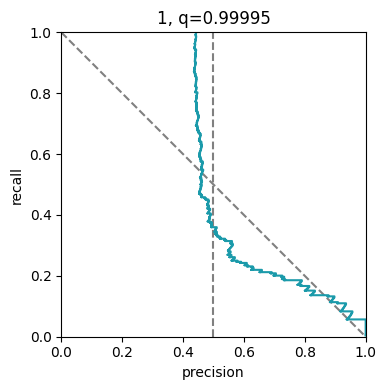

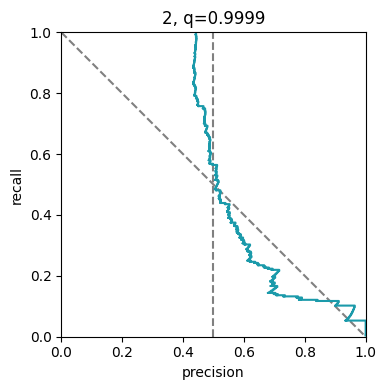

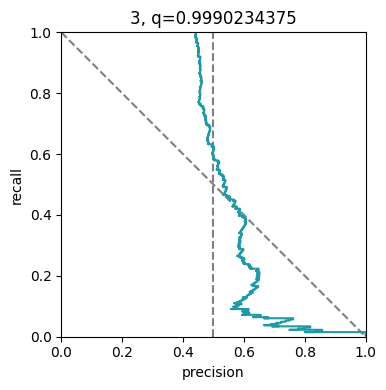

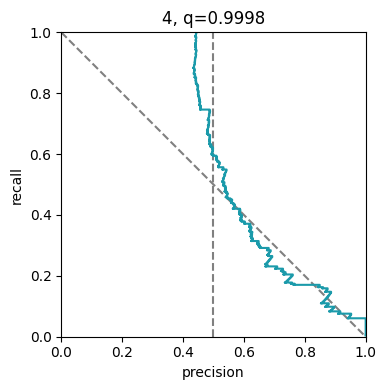

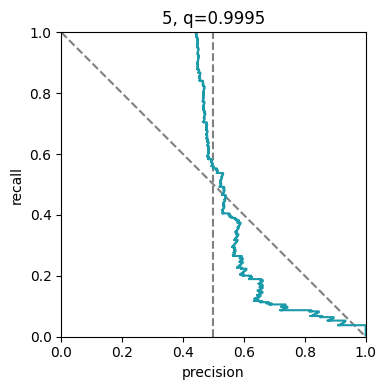

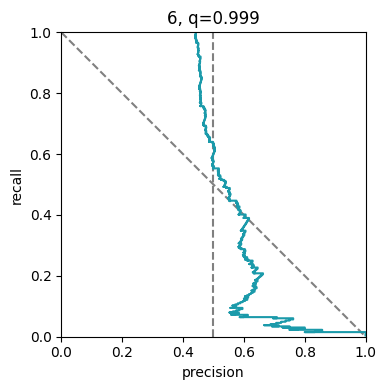

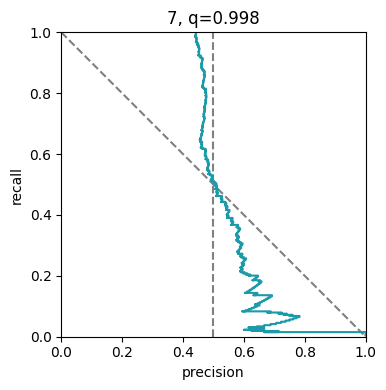

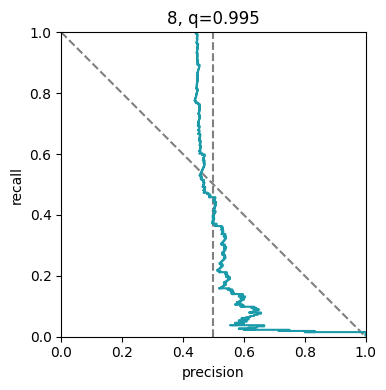

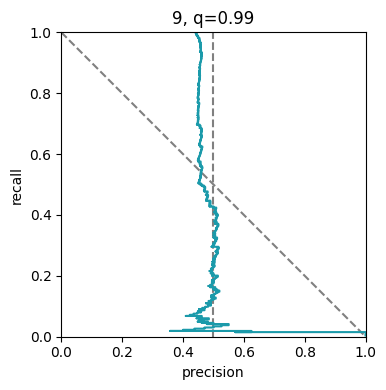

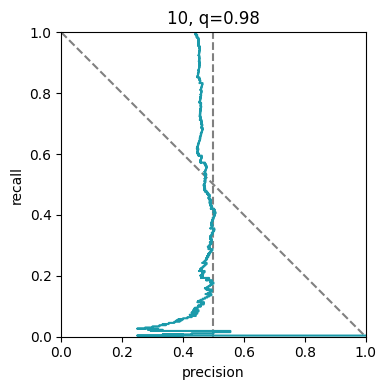

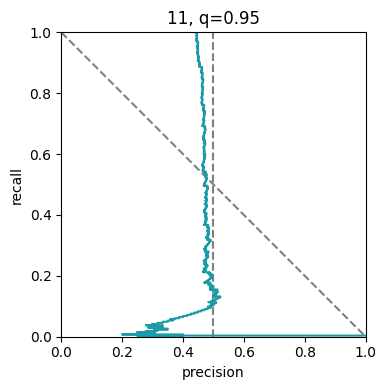

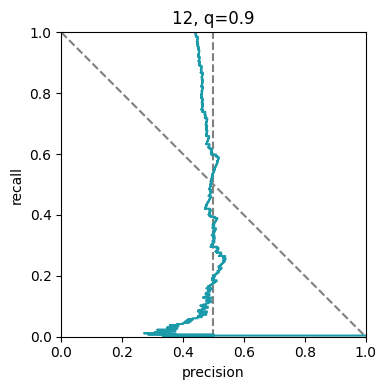

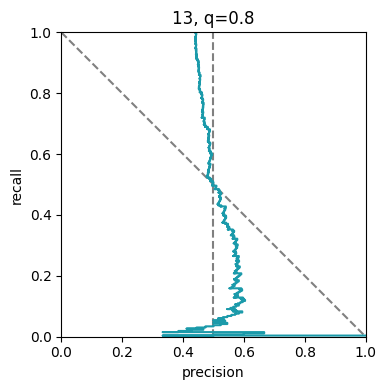

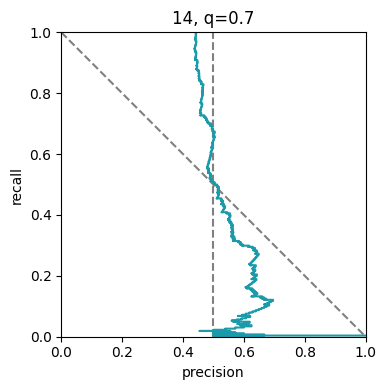

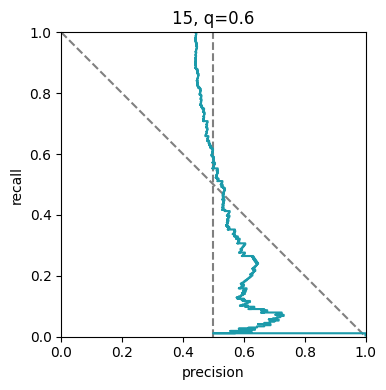

In [45]:
eps = 1e-12

for k in range(len(quantiles_train[0]) - 1):
    y_pred = np.array(quantiles_val)[:, k]
    precisions = []
    recalls = []
    
    for t in sorted(set(y_pred)):
    
        y_pred_binary = y_pred >= t
        TP = ((y_pred_binary == 1) & (repertoire_labels.numpy() == 1)).sum()
        P = (repertoire_labels.numpy() == 1).sum()
        PP = (y_pred_binary == 1).sum()
        precision = TP / (PP + eps)
        recall = TP / (P + eps)
        precisions.append(precision.item())
        recalls.append(recall.item())
    

    # pr_pairs = sorted(zip(precisions, recalls))
    # precisions = [p for p, r in pr_pairs]
    # recalls = [r for p, r in pr_pairs]
    
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
    
    
    
    ax.axvline(0.5, color="grey", linestyle="--")
    ax.plot([0, 1], [1, 0], color="grey", linestyle="--")
    
    ax.plot(np.repeat(precisions, 2)[:-1], np.repeat(recalls, 2)[1:], color=color_3)
    # ax.set_yscale("log")
    
    ax.set_xlim((0, 1))
    ax.set_ylim((0, 1))
    
    ax.set_xlabel("precision")
    ax.set_ylabel("recall")

    
    ax.set_title(f"{k}, q={qs[k]}")
    
    ax.set_aspect("equal")
    fig.tight_layout()
    fig.show()



# precision, recall, 2 * precision * recall / (precision + recall)



# xx_pos = np.array(quantiles_val)[:, k][repertoire_labels == 1]
# xx_neg = np.array(quantiles_val)[:, k][repertoire_labels == 0]
# repertoire_labels[xx < t].float().mean()# == repertoire_labels

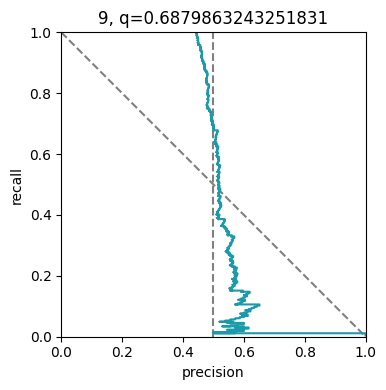

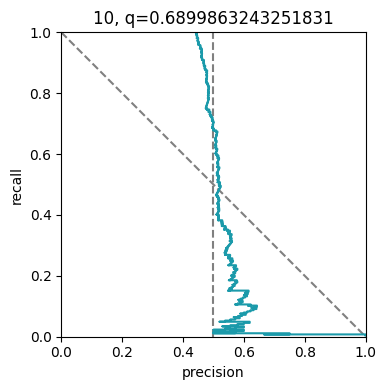

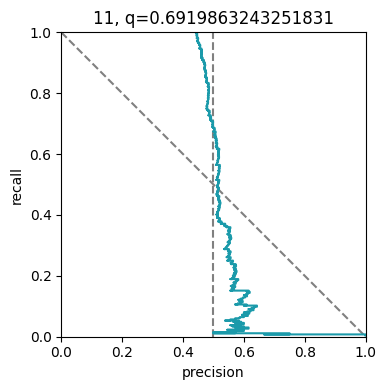

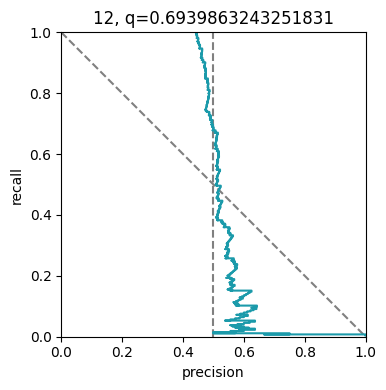

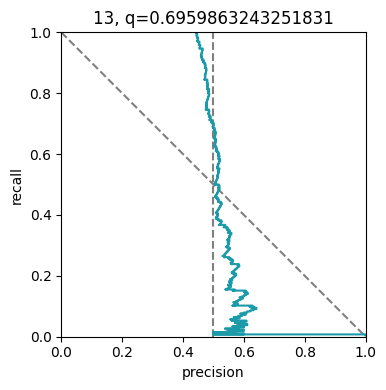

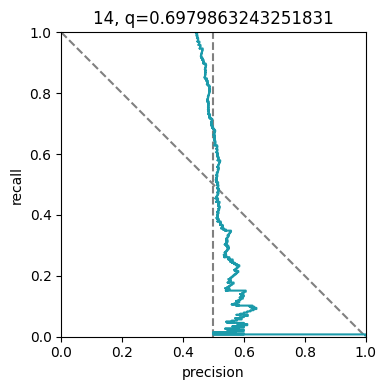

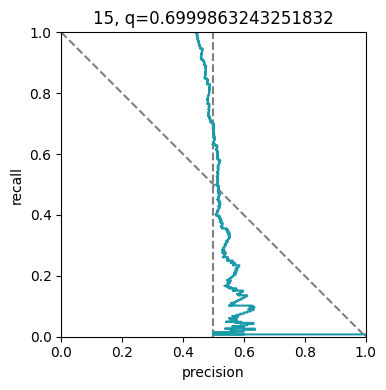

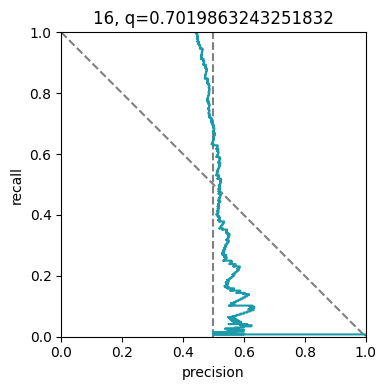

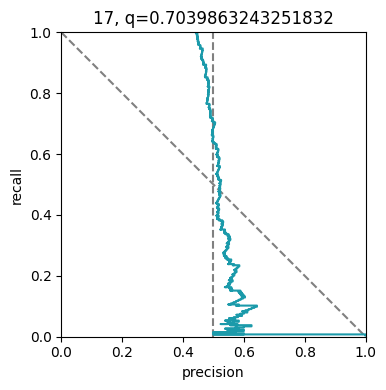

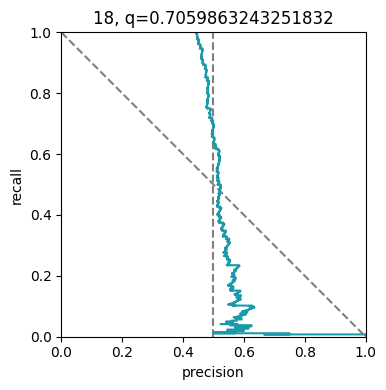

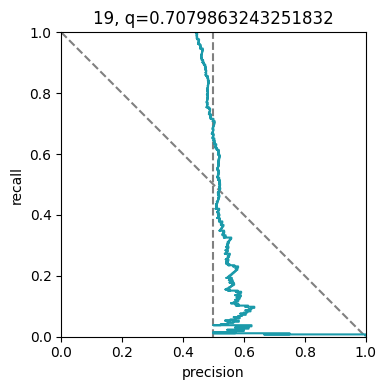

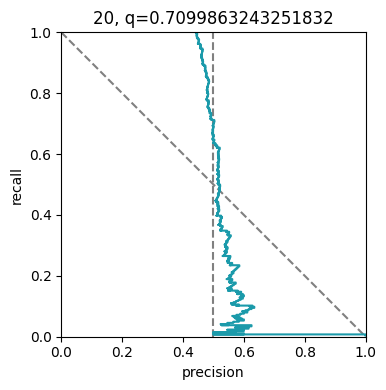

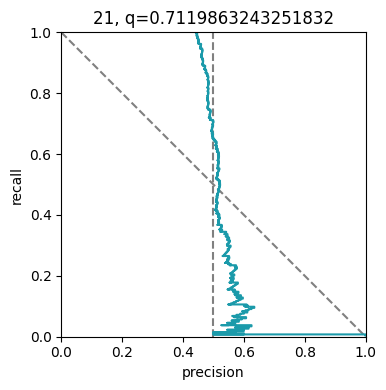

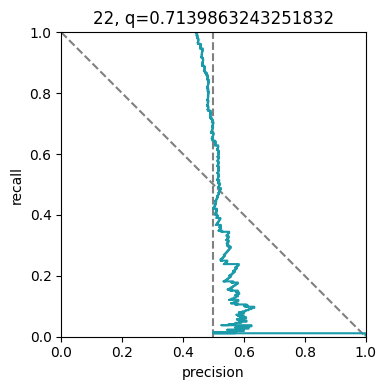

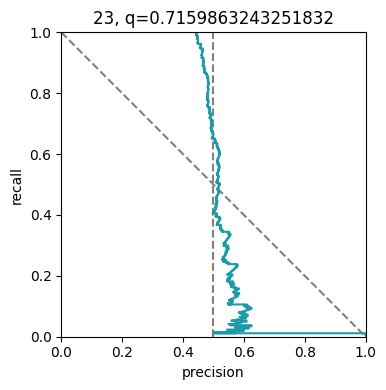

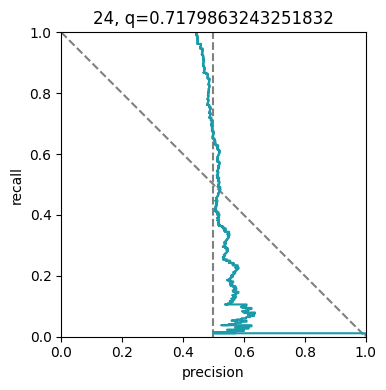

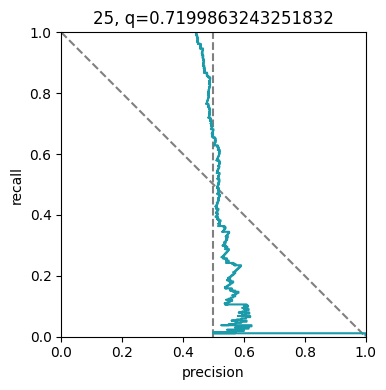

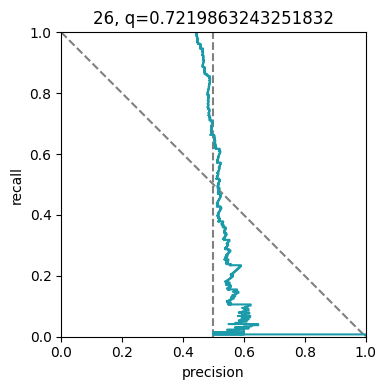

In [277]:
eps = 1e-12

for k in range(9, 27):
    y_pred = np.array(quantiles_val)[:, k]
    precisions = []
    recalls = []
    
    for t in sorted(set(y_pred)):
    
        y_pred_binary = y_pred >= t
        TP = ((y_pred_binary == 1) & (repertoire_labels.numpy() == 1)).sum()
        P = (repertoire_labels.numpy() == 1).sum()
        PP = (y_pred_binary == 1).sum()
        precision = TP / (PP + eps)
        recall = TP / (P + eps)
        precisions.append(precision.item())
        recalls.append(recall.item())
    

    # pr_pairs = sorted(zip(precisions, recalls))
    # precisions = [p for p, r in pr_pairs]
    # recalls = [r for p, r in pr_pairs]
    
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
    
    
    
    ax.axvline(0.5, color="grey", linestyle="--")
    ax.plot([0, 1], [1, 0], color="grey", linestyle="--")
    
    ax.plot(np.repeat(precisions, 2)[:-1], np.repeat(recalls, 2)[1:], color=color_3)
    # ax.set_yscale("log")
    
    ax.set_xlim((0, 1))
    ax.set_ylim((0, 1))
    
    ax.set_xlabel("precision")
    ax.set_ylabel("recall")

    
    ax.set_title(f"{k}, q={qs[k]}")
    
    ax.set_aspect("equal")
    fig.tight_layout()
    fig.show()



# precision, recall, 2 * precision * recall / (precision + recall)



# xx_pos = np.array(quantiles_val)[:, k][repertoire_labels == 1]
# xx_neg = np.array(quantiles_val)[:, k][repertoire_labels == 0]
# repertoire_labels[xx < t].float().mean()# == repertoire_labels

In [176]:
xx_pos.mean()

np.float64(0.6724271097900331)

In [177]:
xx_neg.mean()

np.float64(0.514246472766497)

In [104]:
(np.array(quantiles_train)[:, k] > t) == repertoire_labels

tensor([False, False,  True,  True,  True,  True,  True, False,  True, False,
        False, False,  True, False, False, False,  True, False, False,  True,
        False,  True, False, False,  True, False, False,  True,  True,  True,
        False,  True,  True, False,  True,  True, False,  True,  True, False,
         True,  True, False,  True,  True, False,  True, False,  True, False,
         True, False, False, False,  True,  True,  True,  True, False,  True,
         True, False,  True, False,  True, False, False,  True,  True,  True,
         True,  True,  True,  True,  True, False,  True,  True, False,  True,
         True, False,  True, False, False,  True,  True,  True,  True, False,
        False,  True,  True,  True,  True,  True,  True, False, False,  True,
         True,  True, False,  True,  True,  True,  True,  True, False, False,
         True, False,  True,  True,  True,  True,  True,  True,  True,  True,
         True, False, False,  True, False,  True, False,  True, 

In [99]:
clf.feature_importances_

array([1.])

In [90]:
1 == True

True

In [52]:
clf.feature_importances_

array([0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.14 , 0.184, 0.196, 0.254, 0.226])

In [27]:
clf.predict(np.array(quantiles_val))

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,

In [11]:
signal_intensities.shape

torch.Size([251847])

In [16]:
repertoire_labels

tensor([1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
        0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
        0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
        0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
        1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
        0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
        0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
        1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
        0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0,
        1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [59]:
repertoire_labels

tensor([1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
        0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
        0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
        0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
        1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
        0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
        0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
        1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
        0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0,
        1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [57]:
l = model.sequence_to_latent(x_batch_SP)
(torch.argmax(model.decoder(l), dim=2) == x_batch_SP).float().mean()

tensor(0.9624, device='cuda:0')

In [53]:
torch.nn.functional.softmax(model.decoder(l[:1])[:1], dim=2)

tensor([[[0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422,
          0.0422, 0.0422, 0.0422, 0.0422, 0.1146, 0.0422, 0.0422, 0.0422,
          0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.1146, 0.0422, 0.0422,
          0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422,
          0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.1146, 0.0422, 0.0422,
          0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422,
          0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422,
          0.0422, 0.0422, 0.1146, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422,
          0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422,
          0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.1146, 0.0422, 0.0422,
          0.0422, 0.0422

In [42]:
torch.nn.functional.softmax(model.decoder(l), dim=2)

tensor([[[0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.0422],
         ...,
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.1146],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.1146],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.1146]],

        [[0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.0422],
         ...,
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.1146],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.1146],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.1146]],

        [[0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.

In [ ]:
model.sequence_to_latent(x_batch_SP)

In [ ]:
model()

In [17]:
(torch.argmax(self_predictions['decoded_sequences'], dim=2) == x_batch_SP).float().mean()

tensor(0.0214, device='cuda:0')

In [20]:
with torch.no_grad():
    print(criterion(self_predictions, self_targets))

{'total_loss': tensor(1.5292, device='cuda:0'), 'reconstruction_accuracy': tensor(0.6700, device='cuda:0'), 'kl_divergence': tensor(5.3490, device='cuda:0'), 'tm_loss': tensor(0.0014, device='cuda:0'), 'label_accuracy': tensor(0.5578, device='cuda:0')}


In [26]:
-(torch.log(self_predictions['tm_likelihoods']) * sequence_repertoire_indicators + \
 torch.log(1 - self_predictions['tm_likelihoods']) * (1 - sequence_repertoire_indicators)).mean()

tensor(0.0014, device='cuda:0', grad_fn=<NegBackward0>)

In [27]:
-(torch.log(other_predictions['tm_likelihoods']) * (1 - sequence_repertoire_indicators) + \
 torch.log(1 - other_predictions['tm_likelihoods']) * (sequence_repertoire_indicators)).mean()

tensor(6.7949, device='cuda:0', grad_fn=<NegBackward0>)

In [28]:
other_loss

{'total_loss': tensor(4.8922, device='cuda:0', grad_fn=<AddBackward0>),
 'reconstruction_accuracy': tensor(0.6697, device='cuda:0'),
 'kl_divergence': tensor(5.3657, device='cuda:0', grad_fn=<MeanBackward0>),
 'tm_loss': tensor(6.7949, device='cuda:0', grad_fn=<NegBackward0>),
 'label_accuracy': tensor(0.4422, device='cuda:0')}

In [29]:
self_loss

{'total_loss': tensor(1.5292, device='cuda:0', grad_fn=<AddBackward0>),
 'reconstruction_accuracy': tensor(0.6700, device='cuda:0'),
 'kl_divergence': tensor(5.3490, device='cuda:0', grad_fn=<MeanBackward0>),
 'tm_loss': tensor(0.0014, device='cuda:0', grad_fn=<NegBackward0>),
 'label_accuracy': tensor(0.5578, device='cuda:0')}

In [13]:
self_predictions["tm_likelihoods"]

tensor([0.9991, 0.9991, 0.9985,  ..., 0.9971, 0.9991, 0.9994], device='cuda:0',
       grad_fn=<SumBackward1>)

In [14]:
other_predictions["tm_likelihoods"]

tensor([0.9993, 0.9996, 0.9992,  ..., 0.9986, 0.9988, 0.9993], device='cuda:0',
       grad_fn=<SumBackward1>)

In [15]:
sequence_repertoire_indicators

tensor([1, 1, 1,  ..., 1, 1, 1], device='cuda:0')

In [16]:
1 - sequence_repertoire_indicators

tensor([0, 0, 0,  ..., 0, 0, 0], device='cuda:0')

In [18]:
self_targets["sequence_repertoire_indicators"]

tensor([1, 1, 1,  ..., 1, 1, 1], device='cuda:0')

In [ ]:
model.reconstruct(x_batch_SP, deterministic=True, temperature=0.0)

In [ ]:
model.reconstruct(x_batch_SP, deterministic=True, temperature=0.0)

In [ ]:
x_batch_SP

In [ ]:
x_batch_SP

In [33]:
model.reconstruct(x_batch_SP)

tensor([[ 5,  5, 11,  ..., 18,  6,  8],
        [ 5,  5, 15,  ...,  6,  8, 17],
        [ 5,  5, 11,  ...,  4,  6,  8],
        ...,
        [ 5,  5, 11,  ..., 10,  4, 12],
        [ 5,  5, 11,  ..., 18,  6,  8],
        [ 5,  5, 17,  ..., 10, 18, 10]], device='cuda:0')

In [ ]:
with torch.no_grad():
    display(criterion.ce_loss(other_predictions['decoded_sequences'].permute(0, 2, 1), x_batch_SP))

In [ ]:
# other_predictions['decoded_sequences']

In [ ]:
(torch.argmax(other_predictions['decoded_sequences'], dim=2) == x_batch_SP)

In [28]:
torch.argmax(other_predictions['decoded_sequences'], dim=2)

tensor([[12,  6,  5,  ..., 21, 21, 21],
        [12,  5,  5,  ..., 21, 21, 21],
        [12,  5,  5,  ..., 21, 21, 21],
        ...,
        [12,  5,  8,  ..., 21, 21, 21],
        [12,  5,  5,  ..., 21, 21, 21],
        [12,  5,  5,  ..., 21, 21, 21]], device='cuda:0')



 90%|█████████████████████████████████████████████████████      | 253/281 [00:21<00:00, 36.04it/s, batch=251, kl_d=3.03, label_acc=3.03, rec_acc=0.965, tm=3.03, total=3.03]

In [15]:
torch.nn.CrossEntropyLoss()(other_predictions['decoded_sequences'].permute(0, 2, 1), x_batch_SP)

tensor(2.5943, device='cuda:0')

In [15]:
torch.argmax(other_predictions['decoded_sequences'], dim=2)

tensor([[21, 21, 21,  ..., 21, 21, 21],
        [21, 21, 21,  ..., 21, 21, 21],
        [21, 21, 21,  ..., 21, 21, 21],
        ...,
        [21, 21, 21,  ..., 21, 21, 21],
        [21, 21, 21,  ..., 21, 21, 21],
        [21, 21, 21,  ..., 21, 21, 21]], device='cuda:0')

In [16]:
(x_batch_SP == 21).to(torch.float).mean()

tensor(0.5192, device='cuda:0')

In [24]:
other_predictions['decoded_sequences']

tensor([[[2.5989e-05, 4.9384e-05, 3.3069e-05,  ..., 4.4348e-05,
          1.6984e-05, 2.1707e-07],
         [3.4209e-05, 6.8436e-05, 4.0693e-05,  ..., 5.8893e-05,
          2.2980e-05, 7.4785e-08],
         [3.3625e-05, 6.7439e-05, 4.1100e-05,  ..., 5.9450e-05,
          2.3383e-05, 6.5875e-08],
         ...,
         [6.0871e-11, 3.4016e-11, 1.0762e-10,  ..., 6.0387e-11,
          1.7119e-11, 1.0000e+00],
         [5.9393e-11, 3.4967e-11, 1.1187e-10,  ..., 6.0369e-11,
          1.6305e-11, 1.0000e+00],
         [3.3356e-11, 1.8263e-11, 5.8997e-11,  ..., 3.5116e-11,
          9.2645e-12, 1.0000e+00]],

        [[2.5253e-05, 4.6327e-05, 3.2127e-05,  ..., 4.2645e-05,
          1.5792e-05, 2.8645e-07],
         [3.3533e-05, 6.5404e-05, 3.9497e-05,  ..., 5.7121e-05,
          2.1538e-05, 9.4364e-08],
         [3.1365e-05, 6.2899e-05, 4.0177e-05,  ..., 5.6767e-05,
          2.1140e-05, 1.0024e-07],
         ...,
         [6.1523e-11, 3.3872e-11, 1.0995e-10,  ..., 6.1375e-11,
          1.732